# Análise das redes sociais declaradas por candidatos

Durante o processo de registro de candidatura, os candidatos informam ao Tribunal Superior Eleitoral (TSE) dados referentes à sua candidatura, incluindo as contas e canais de redes sociais que utilizam para divulgação de sua campanha. Essas informações são disponibilizadas publicamente pelo TSE por meio do conjunto de [Dados Abertos de Candidatos](https://dadosabertos.tse.jus.br/dataset/candidatos-2026), incluindo o arquivo `rede_social_candidato`, que registra as URLs declaradas pelos candidatos.

Este notebook analisa a **quantidade de redes sociais declaradas por candidato**, utilizando como unidade de contagem cada URL registrada para uma candidatura. A análise busca caracterizar a distribuição desse indicador entre os candidatos e identificar eventuais valores discrepantes (*outliers*).


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Carregando dados

In [85]:
df_candidate = pd.read_csv(os.path.join('..', 'dados', 'consulta_cand_2026_BRASIL.csv'), sep = ';', encoding='latin1', low_memory=False)
df_social_media = pd.read_csv(os.path.join('..', 'dados', 'rede_social_candidato_2026_BRASIL.csv'), sep = ';', encoding='latin1', low_memory=False)

In [86]:
print(df_candidate.info())
df_candidate.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20989 entries, 0 to 20988
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   DT_GERACAO                     20989 non-null  object
 1   HH_GERACAO                     20989 non-null  object
 2   ANO_ELEICAO                    20989 non-null  int64 
 3   CD_TIPO_ELEICAO                20989 non-null  int64 
 4   NM_TIPO_ELEICAO                20989 non-null  object
 5   NR_TURNO                       20989 non-null  int64 
 6   CD_ELEICAO                     20989 non-null  int64 
 7   DS_ELEICAO                     20989 non-null  object
 8   DT_ELEICAO                     20989 non-null  object
 9   TP_ABRANGENCIA                 20989 non-null  object
 10  SG_UF                          20989 non-null  object
 11  SG_UE                          20989 non-null  object
 12  NM_UE                          20989 non-null  object
 13  C

,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO
7753,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,6,ENSINO MÉDIO COMPLETO,3,CASADO(A),3,PARDA,297,SERVIDOR PÚBLICO ESTADUAL,4,NÃO ELEITO
15848,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,8,SUPERIOR COMPLETO,3,CASADO(A),3,PARDA,257,EMPRESÁRIO,5,SUPLENTE
19134,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),3,PARDA,298,SERVIDOR PÚBLICO MUNICIPAL,5,SUPLENTE
18493,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,7,SUPERIOR INCOMPLETO,1,SOLTEIRO(A),1,BRANCA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",-1,#NULO
16368,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,923,APOSENTADO (EXCETO SERVIDOR PÚBLICO),5,SUPLENTE


In [87]:
len(df_candidate)

20989

In [88]:
print(df_social_media.info())
df_social_media.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63199 entries, 0 to 63198
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   DT_GERACAO            63199 non-null  object
 1   HH_GERACAO            63199 non-null  object
 2   AA_ELEICAO            63199 non-null  int64 
 3   SG_UF                 63199 non-null  object
 4   CD_TIPO_ELEICAO       63199 non-null  int64 
 5   NM_TIPO_ELEICAO       63199 non-null  object
 6   CD_ELEICAO            63199 non-null  int64 
 7   DS_ELEICAO            63199 non-null  object
 8   SQ_CANDIDATO          63199 non-null  int64 
 9   NR_ORDEM_REDE_SOCIAL  63199 non-null  int64 
 10  DS_URL                63199 non-null  object
dtypes: int64(5), object(6)
memory usage: 5.3+ MB
None


,DT_GERACAO,HH_GERACAO,AA_ELEICAO,SG_UF,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,CD_ELEICAO,DS_ELEICAO,SQ_CANDIDATO,NR_ORDEM_REDE_SOCIAL,DS_URL
5146,05/10/2026,10:13:17,2026,MT,2,ELEIÇÃO ORDINÁRIA,6259,ELEIÇÕES GERAIS ESTADUAIS 2026,110002540131,2,https://www.facebook.com/nerigelleroficial?mib...
27078,05/10/2026,10:13:17,2026,RS,2,ELEIÇÃO ORDINÁRIA,6259,ELEIÇÕES GERAIS ESTADUAIS 2026,210002538556,3,HTTP://WWW.HEITORSCHUCH.COM.BR
14391,05/10/2026,10:13:17,2026,ES,2,ELEIÇÃO ORDINÁRIA,6259,ELEIÇÕES GERAIS ESTADUAIS 2026,80002553269,3,https://www.threads.com/@maguinhamalta?igshid=...
8016,05/10/2026,10:13:17,2026,SP,2,ELEIÇÃO ORDINÁRIA,6259,ELEIÇÕES GERAIS ESTADUAIS 2026,250002530218,9,https://www.facebook.com/share/19VBz1eikY/
34776,05/10/2026,10:13:17,2026,RO,2,ELEIÇÃO ORDINÁRIA,6259,ELEIÇÕES GERAIS ESTADUAIS 2026,220002539755,5,https://www.facebook.com/alan.sistemas


# Filtragem e cruzamento de dados

In [89]:
# map a candidate ID to the number of social media links they have
map_candidate_id_to_number_of_links = dict(df_social_media['SQ_CANDIDATO'].value_counts())

# add a new column to df_candidate with the number of social media links
df_candidate['NUMERO_DE_LINKS'] = df_candidate['SQ_CANDIDATO'].map(map_candidate_id_to_number_of_links).fillna(0).astype(int)

# create a column with name, party and UE
df_candidate['CANDIDATO_PARTIDO_UE'] = df_candidate['NM_CANDIDATO'] + ' (' + df_candidate['SG_PARTIDO'] + ' - ' + df_candidate['SG_UE'] + ')'

In [90]:
main_columns = ['CANDIDATO_PARTIDO_UE', 'DS_CARGO', 'NUMERO_DE_LINKS']

# Candidatos com maior número de redes sociais declaradas

In [91]:
# top k candidates with the most social media links
k = 15
top_k_candidates = df_candidate.sort_values(by='NUMERO_DE_LINKS', ascending=False).head(k)[main_columns]
print(f'Top {k} candidatos com mais redes sociais declaradas:')
top_k_candidates

Top 15 candidatos com mais redes sociais declaradas:


,CANDIDATO_PARTIDO_UE,DS_CARGO,NUMERO_DE_LINKS
12726,ANDRE FERNANDES DE MOURA (PL - CE),DEPUTADO FEDERAL,913
4838,ELMANO DE FREITAS DA COSTA (PT - CE),GOVERNADOR,245
4207,JOSÉ RENATO CASAGRANDE (PSB - ES),SENADOR,84
10064,CIRO FERREIRA GOMES (PSDB - CE),GOVERNADOR,66
2308,PRISCILA BEZERRA DA COSTA (PL - CE),DEPUTADO FEDERAL,52
20835,MATHEUS ARAUJO LAIOLA (UNIÃO - PR),DEPUTADO FEDERAL,51
7455,LUIZ INÁCIO LULA DA SILVA (PT - BR),PRESIDENTE,49
2260,FLAVIO NANTES BOLSONARO (PL - BR),PRESIDENTE,46
15705,BRUNO SCHEID (PL - RO),SENADOR,40
9557,CIRO NOGUEIRA LIMA FILHO (PP - PI),SENADOR,38


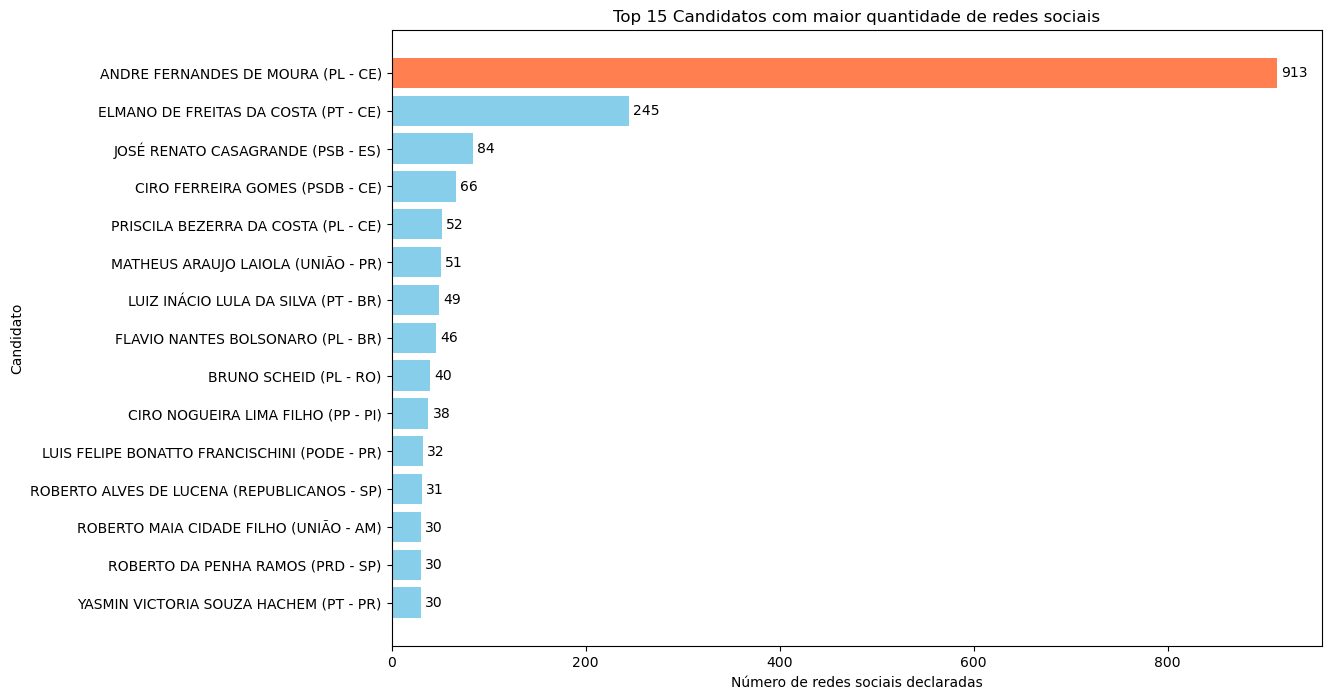

In [98]:
# plot quantitative distribution of the number of social media links of top_k_candidates
plt.figure(figsize=(12, 8))
bar_colors = ['coral' if i == 0 else 'skyblue' for i in range(len(top_k_candidates))]
bars = plt.barh(top_k_candidates['CANDIDATO_PARTIDO_UE'], top_k_candidates['NUMERO_DE_LINKS'], color=bar_colors)
plt.bar_label(bars, fmt='%.0f', padding=3)
plt.xlabel('Número de redes sociais declaradas')
plt.ylabel('Candidato')
plt.title('Top {} Candidatos com maior quantidade de redes sociais'.format(k))
plt.gca().invert_yaxis()
plt.show()

# Análise da distribuição

In [93]:
df_candidate['NUMERO_DE_LINKS'].describe().round(0)

count    20989.0
mean         3.0
std          7.0
min          0.0
25%          1.0
50%          2.0
75%          4.0
max        913.0
Name: NUMERO_DE_LINKS, dtype: float64

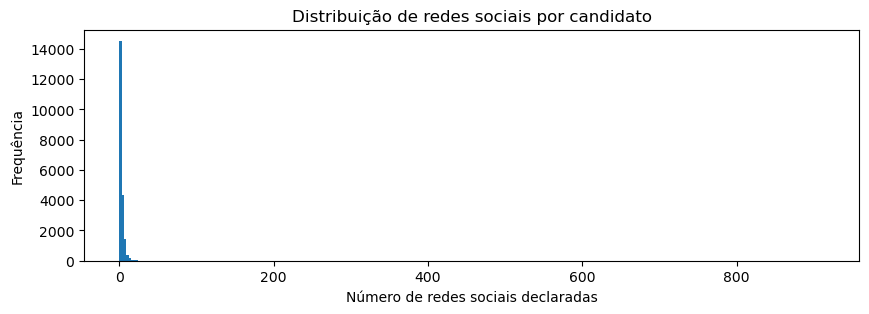

In [94]:
# plot the distribution of the number of social media links
plt.figure(figsize=(10, 3))
plt.hist(df_candidate['NUMERO_DE_LINKS'], bins=300)
plt.xlabel('Número de redes sociais declaradas')
plt.ylabel('Frequência')
plt.title('Distribuição de redes sociais por candidato')
plt.show()

In [95]:
# 90 percentile of the number of social media links
np.percentile(df_candidate['NUMERO_DE_LINKS'], 95)

np.float64(8.0)

95% dos candidatos declararam menos de 10 links de redes sociais. André Fernandes declarou **913** redes sociais. A maioria links de grupos de Whatsapp que estão atualmente desativados. Podem ser verificados [aqui](https://divulgacandcontas.tse.jus.br/divulga/#/candidato/NORDESTE/CE/20322002026/60002536979/2026/CE).

## Candidatos sem redes sociais

In [96]:
# count of candidates with 0 social media links
num_candidates_with_no_links = (df_candidate['NUMERO_DE_LINKS'] == 0).sum()
print(f'Número de candidatos com 0 redes sociais declaradas: {num_candidates_with_no_links}')
print(f'Proporção de candidatos com 0 redes sociais declaradas: {num_candidates_with_no_links / len(df_candidate) * 100:.2f}%')

Número de candidatos com 0 redes sociais declaradas: 2455
Proporção de candidatos com 0 redes sociais declaradas: 11.70%


11% dos candidatos não declararam nenhuma rede social. Filtrando esses candidatos, obtemos uma distribuição diferente:

In [97]:
df_candidates_with_links = df_candidate[df_candidate['NUMERO_DE_LINKS'] > 0]
df_candidates_with_links['NUMERO_DE_LINKS'].describe().round(0)

count    18534.0
mean         3.0
std          8.0
min          1.0
25%          1.0
50%          2.0
75%          4.0
max        913.0
Name: NUMERO_DE_LINKS, dtype: float64